#  Mini Project 3: Iris Flower Clustering using K-Means

### Machine Learning | Unsupervised Learning | Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)

Dataset Shape: (150, 4)


In [3]:
df = pd.DataFrame(X, columns=iris.feature_names)

df["True_Label"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True_Label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(X)

clusters = kmeans.labels_

df["Cluster"] = clusters

## Assignment 1: Perform K-Means on the Iris Dataset and Visualize the Clusters

In [5]:
print(kmeans.cluster_centers_)

[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


In [6]:
comparison = pd.DataFrame({
    "True Label": y,
    "Predicted Cluster": clusters
})

comparison.head(20)

,True Label,Predicted Cluster
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
5,0,1
6,0,1
7,0,1
8,0,1
9,0,1


In [7]:
cm = confusion_matrix(y, clusters)

print(cm)

[[ 0 50  0]
 [ 3  0 47]
 [36  0 14]]


## 🎯 Assignment 2: Apply Principal Component Analysis (PCA)

In [8]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

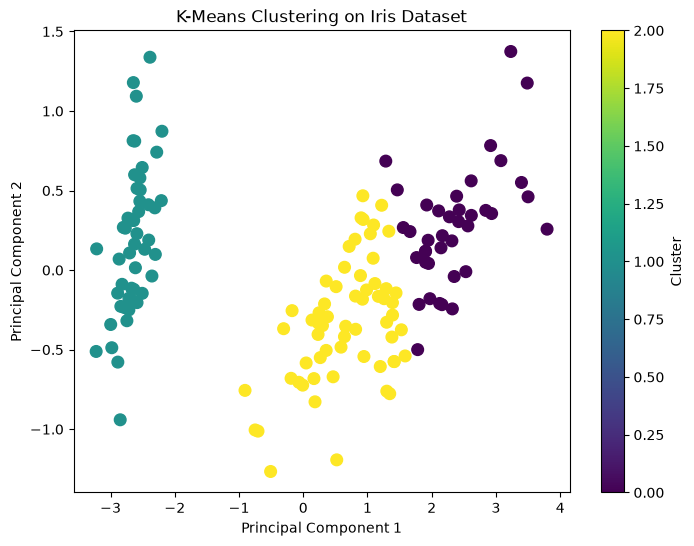

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis',
    s=70
)

plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")
plt.show()

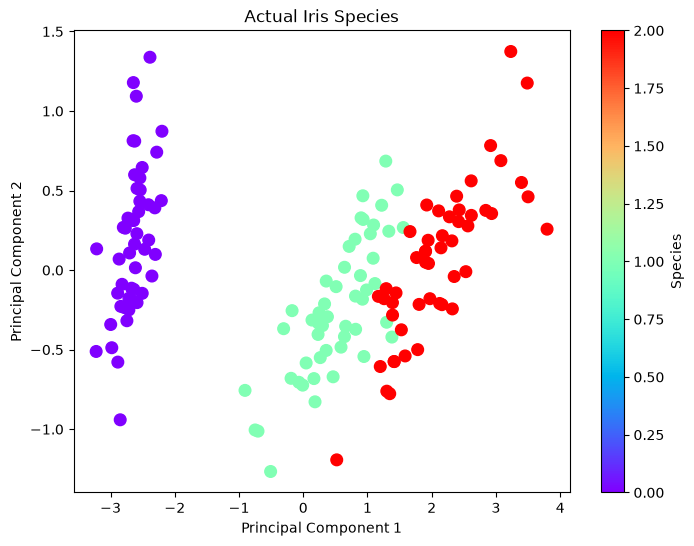

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='rainbow',
    s=70
)

plt.title("Actual Iris Species")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Species")
plt.show()

In [11]:
print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.92461872 0.05306648]


## Conclusion

In this project, K-Means clustering was applied to the Iris dataset with three clusters. Since K-Means is an unsupervised learning algorithm, it grouped the flowers based only on feature similarity without using the actual species labels.

Principal Component Analysis (PCA) was used to reduce the dataset from four dimensions to two dimensions for visualization. The scatter plots showed that the algorithm successfully identified the natural grouping of the Iris flowers, especially separating Setosa from the other two species.

The Adjusted Rand Index demonstrated that the clustering performance was good, indicating that K-Means can effectively discover hidden patterns in the dataset.